In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect
import pandas as pd
import equivalent_conductivity as eq
import multicomponent_conductivity as mc

# Conductivity of Simple Ionic Mixtures

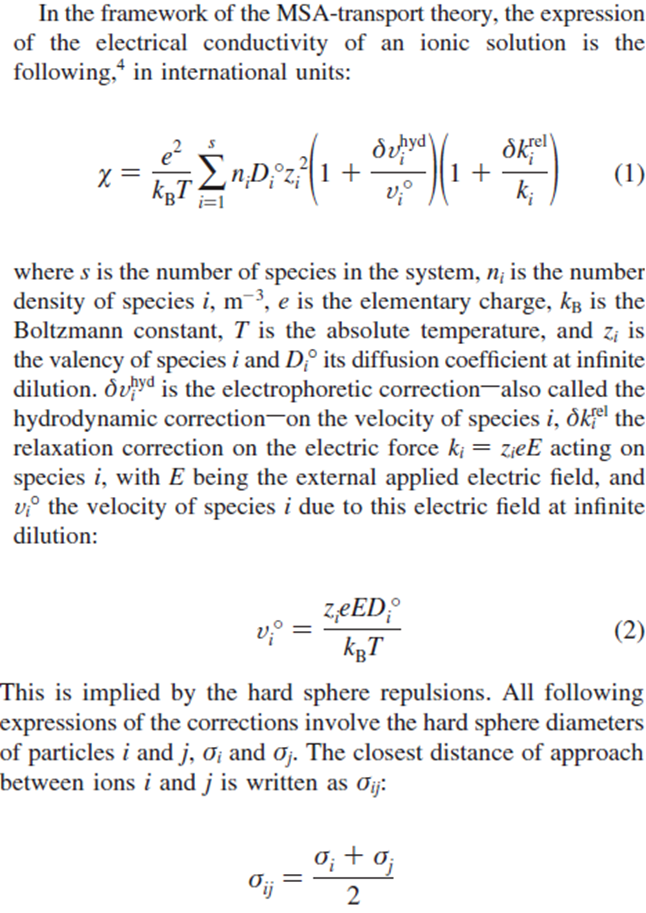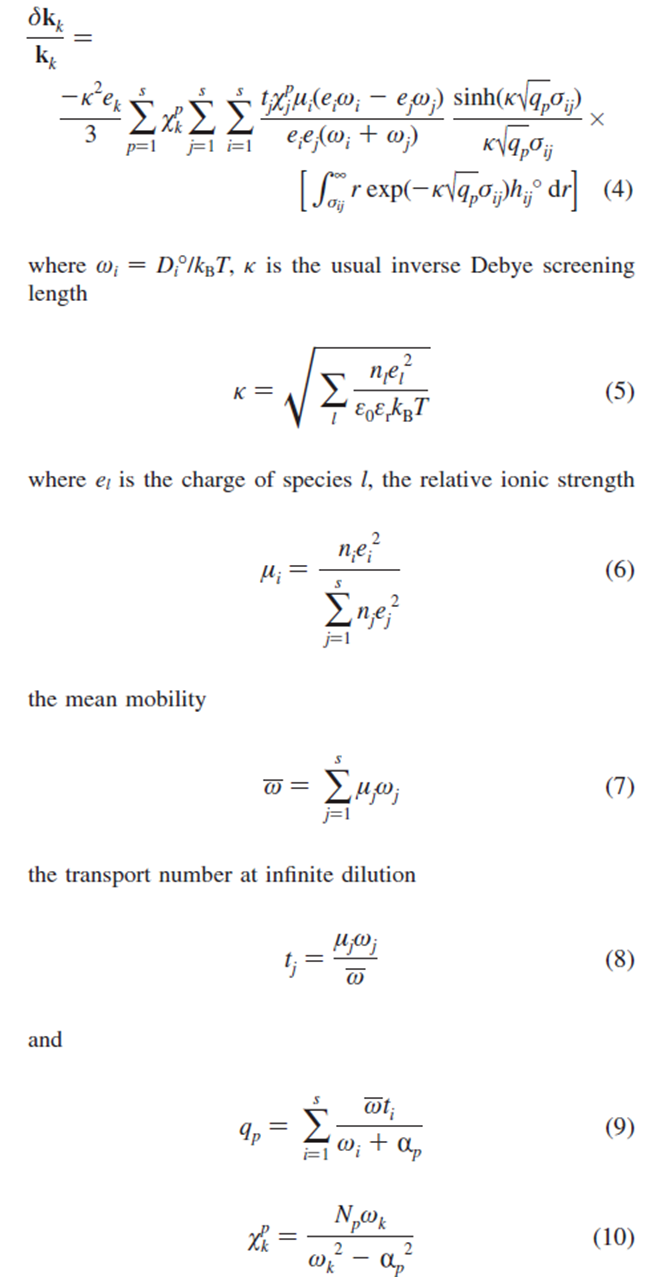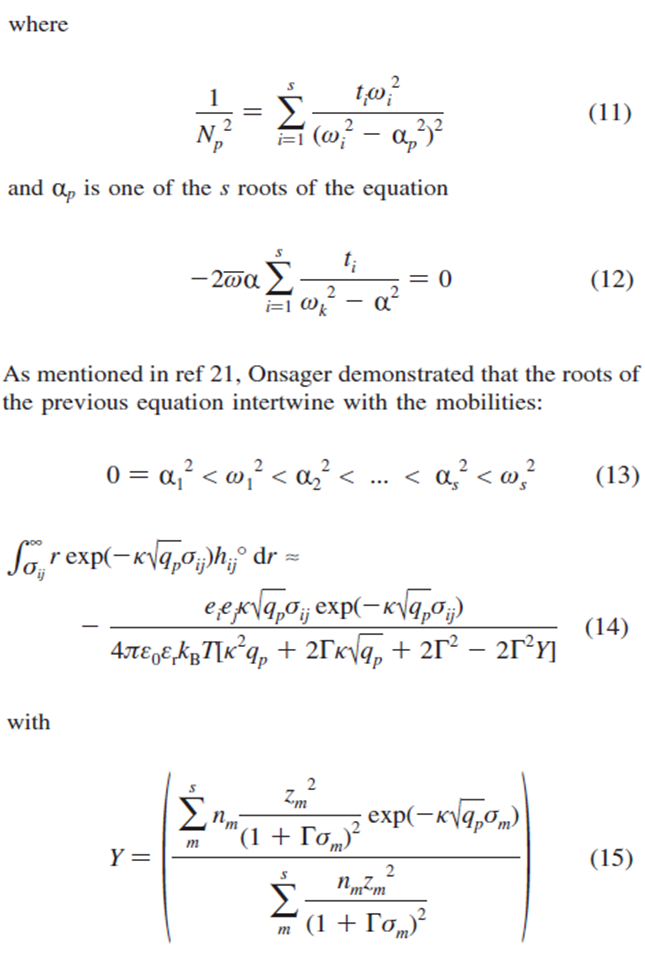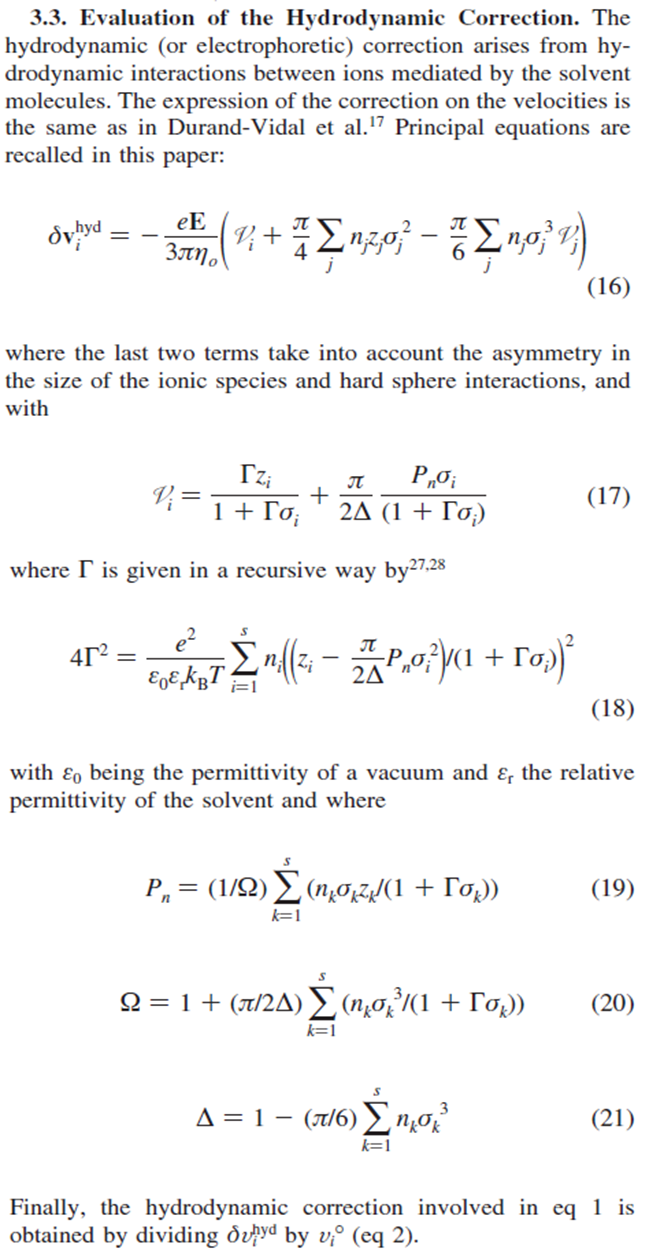

# Double Salts Prediction

## Data for Double Salts

In [2]:
# loading NaCl and CaCl2 experiment data
data = pd.read_csv("./Data/NaCl_CaCl2_rearranged.csv")
NaCl_conc = data["NaCl conc"]
NaCl_conc12 = data["NaCl conc2"]
NaCl_conc13 = data["NaCl conc3"]
CaCl2_conc = data["CaCl2 conc"]
CaCl2_conc12 = data["CaCl2 conc2"]
CaCl2_conc13 = data["CaCl2 conc3"]
cond_exp = data["Cal bulk cond"]
cond_exp12 = data["Cal bulk cond2"]
cond_exp13 = data["Cal bulk cond3"]
# cond_exp = data["Bulk cond"]
# cond_exp12 = data["Bulk cond2"]
# cond_exp13 = data["Bulk cond3"]


# number of data points
ndata = len(cond_exp)

In [3]:
# loading CaCl2 and LaCl3 experiment data
data2 = pd.read_csv("./Data/CaCl2_LaCl3_rearranged.csv")
LaCl3_conc = data2["LaCl3 conc"]
LaCl3_conc12 = data2["LaCl3 conc2"]
LaCl3_conc13 = data2["LaCl3 conc3"]
CaCl2_conc2 = data2["CaCl2 conc"]
CaCl2_conc22 = data2["CaCl2 conc2"]
CaCl2_conc23 = data2["CaCl2 conc3"]
cond_exp2 = data2["Cal bulk cond"]
cond_exp22 = data2["Cal bulk cond2"]
cond_exp23 = data2["Cal bulk cond3"]
# cond_exp2 = data2["Bulk cond"]

# number of data points
ndata2 = len(cond_exp2)

In [4]:
# loading NaCl and LaCl3 experiment data
data4 = pd.read_csv("./Data/NaCl_LaCl3_rearranged.csv")
NaCl_conc2 = data4["NaCl conc"]
NaCl_conc22 = data4["NaCl conc2"]
NaCl_conc23 = data4["NaCl conc3"]
LaCl3_conc2 = data4["LaCl3 conc"]
LaCl3_conc22 = data4["LaCl3 conc2"]
LaCl3_conc23 = data4["LaCl3 conc3"]
cond_exp3 = data4["Cal bulk cond"]
cond_exp32 = data4["Cal bulk cond2"]
cond_exp33 = data4["Cal bulk cond3"]
# cond_exp3 = data4["Bulk cond"]

# number of data points
ndata4 = len(cond_exp3)

## Constants

In [5]:
# temperature
T = 298.15

# diffusion coefficients at infinite dilution
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3

# measuring voltage and probe distance
voltage = 25 * 10**(-3)
distance = 9 * 10**(-6)

# hard sphere diameters
sigma_Cl = 181 * 10**(-12)
sigma_Ca = 100 * 10**(-12)
sigma_La = 103.2 * 10**(-12)
sigma_Na = 102 * 10**(-12)

# solvent viscosity
eta = 0.89 * 10**(-3)

# electric field
E_field = voltage/distance

# relative permittivity
epsilon = 78.4

## MSA Transport Model

In [6]:
# MSA transport model function for specific conductivity calculation
def msa_conductivity_model(valency, diameters, diff_coeff, T, sensor_voltage, probe_distance, eta, epsilon, 
                           cond_exp, salt_1_conc, salt_2_conc=None):
    """Calculates specific conductivity of double salts solution

    Argument:
        valency: list of the valency of ions with cations listed before anions in decreasing order
        diameters: list of the corresponding hard sphere diameter of ions in m
        diff_coeff: list of the corresponding diffusion coefficient at infinite dilution of ions in m^2/s
        T: temperature in K
        sensor_voltage: sensor measuring voltage in V
        probe_distance: distance between probes in m
        eta: viscosity in Pa.s
        epsilon: relative permittivity
        salt_1_conc = concentration of salt 1 from data in mM (Pandas series or list)
        salt_2_conc = concentration of salt 2 from data in mM (Pandas series or list) - optional
        cond_exp: conductivity of solution from data in micro.S/cm (Pandas series or list)

    Returns:
        all_cond_calc_con: specific conductivity in micro.S/cm"""

    # constants
    Avogadros_num = 6.022*10**23 # Avogadro's constant
    k_B = 1.381 * 10**(-23) # Boltzmann constant in J/K
    charge = 1.602 * 10**(-19) # elementary charge in C
    epsilon_0 = 8.854 * 10**(-12) # permittivity of free space in F/m
    
    # electric field
    E_field = sensor_voltage/probe_distance

    # number of data points
    ndata = len(cond_exp)

    # number of species
    n_species = len(valency)

    # species charge
    ion_charge = [valency[i] * charge for i in range(len(valency))]

    # converting molar concentrations to number density
    if salt_2_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cation
        valency_cation = valency[0]

        # evaluating number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_an = [valency_cation * number_density_salt_1[i] for i in range(ndata)]
    else:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_2 = [salt_2_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cations
        valency_cation_1 = valency[0]
        valency_cation_2 = valency[1]

        # evaluating number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_cat_2 = number_density_salt_2
        number_density_an = [valency_cation_1 * number_density_salt_1[i] + valency_cation_2 * number_density_salt_2[i]
                             for i in range(ndata)]

    # conductivity
    all_cond_calc = np.zeros(ndata)

    # for mixture concentration (row) in data
    for n in range(ndata):
        if salt_2_conc is None:
            # number density of species
            n_cat = number_density_cat_1[n]
            n_an = number_density_an[n]
            number_density = [n_cat, n_an]
        else:
            # number density of species
            n_cat_1 = number_density_cat_1[n]
            n_cat_2 = number_density_cat_2[n]
            n_an = number_density_an[n]
            number_density = [n_cat_1, n_cat_2, n_an]

        # evaluating omega and mew for all species
        omega = np.zeros(n_species)
        mew = np.zeros(n_species)
        for a in range(n_species):
            omega[a] = diff_coeff[a]/(k_B*T) 
            mew[a] = number_density[a]*ion_charge[a]**2/sum(number_density[j]*ion_charge[j]**2 for j in range(n_species))
    
        # evaluating kappa from equation (5)
        kappa = math.sqrt(sum(number_density[l]*ion_charge[l]**2/(epsilon*epsilon_0*k_B*T) for l in range(n_species)))
        
        # evaluating the mean mobility, omega_bar from equation (7)
        omega_bar = sum(mew[j]*omega[j] for j in range(n_species))
    
        # evaluating transport number for all species from equation (8)
        transport_num = np.zeros(n_species)
        for j in range(n_species):
            transport_num[j] = mew[j]*omega[j]/omega_bar
        
        # ksi matrix
        ksi = np.zeros((n_species, n_species))
    
        # conductivity of species from equation (1)
        cond_species = np.zeros(n_species)
    
        # calculating delta from equation (21)
        delta = 1 - ((math.pi/6)*sum(number_density[k]*diameters[k]**3 for k in range(n_species)))
    
        # writing a function that evaluates equation (18)
        def func_gamma(gamma):
            """
            Evaluates residual of equation (18)
    
            Arguments:
                gamma
    
            Returns:
                Residual of the equation
            """
            # calculating capital omega from equation (20)
            capital_omega = 1 + ((math.pi/(2*delta))*sum(number_density[k]*diameters[k]**3/(1 + gamma*diameters[k]) for k in range(n_species)))
    
            # calculating Pn from equation (19)
            P_n = (1/capital_omega)*sum(number_density[k]*diameters[k]*valency[k]/(1 + gamma*diameters[k]) for k in range(n_species))
            
            return(4*epsilon_0*gamma**2 - ((charge**2)/(epsilon*k_B*T))*
                   sum(number_density[l]*((valency[l] - (math.pi*P_n*diameters[l]**2/(2*delta)))/(1 + gamma*diameters[l]))**2 for l in range(n_species)))
    
        # finding gamma, the root of equation (18)
        gamma = bisect(func_gamma, 0, 0.5*kappa)
        # print(f"Gamma: {gamma}")
        # print(f"The function value is: {func_gamma(gamma)}")
    
        # re-evaluating capital_omega, P_n and nu
        capital_omega = 1 + ((math.pi/(2*delta))*sum(number_density[k]*diameters[k]**3/(1 + gamma*diameters[k]) for k in range(n_species)))
        P_n = (1/capital_omega)*sum(number_density[k]*diameters[k]*valency[k]/(1 + gamma*diameters[k]) for k in range(n_species))
    
        # nu values for all species from equation (17)
        nu = np.zeros(n_species)
        for k in range(n_species):
            nu[k] = (gamma*valency[k]/(1 + gamma*diameters[k])) + (math.pi/(2*delta))*(P_n*diameters[k]/(1 + gamma*diameters[k]))
    
        # evaluating q and N for all species from equation (9) and (11) respectively
        q = np.zeros(n_species)
        N = np.zeros(n_species)
        alpha_scaled = np.zeros(n_species)
    
        # function that evaluates equation (12)
        def func_alpha(alpha_scaled):
            """ 
            Evaluates residuals of equation 12
    
            Arguments:
                alpha_scaled = alpha/omega_bar
    
            Returns:
                residual of the equation
            """
            return((alpha_scaled)*sum(transport_num[k]/((omega[k]/omega_bar)**2 - (alpha_scaled)**2) for k in range(n_species)))
        
        # since alpha is scaled by omega_bar, the bounds (omega), need to be scaled by same factor
        omega_scaled = np.zeros(n_species)
        if salt_2_conc is None:
            for k in range(n_species):
                if k == 0:
                    omega_scaled[k] = omega[k] / omega_bar
                else:
                    omega_scaled[k] = omega[k] / omega_bar

            # updating the values of alpha_scaled
            for p in range(n_species):
                if p == 0:
                    alpha_scaled[p] = bisect(func_alpha, 0, 0.991 * omega_scaled[p])
                else:
                    alpha_scaled[p] = bisect(func_alpha, 1.001 * omega_scaled[p-1], 0.991 * omega_scaled[p])
        else:
            for k in range(n_species):
                if k == 0:
                    omega_scaled[k] = omega[k] / omega_bar
                elif k == 1:
                    omega_scaled[k] = omega[k] / omega_bar
                else:
                    omega_scaled[k] = omega[k] / omega_bar

            # updating the values of alpha_scaled
            for p in range(n_species):
                if p == 0:
                    alpha_scaled[p] = bisect(func_alpha, 0, 0.991 * omega_scaled[p])
                elif p == 1:
                    alpha_scaled[p] = bisect(func_alpha, 1.001 * omega_scaled[p-1], 0.991 * omega_scaled[p])
                else:
                    alpha_scaled[p] = bisect(func_alpha, 1.001 * omega_scaled[p-1], 0.991 * omega_scaled[p])
    
        # rescaling alpha_scaled back to alpha
        alphas = [alpha_scaled[p]*omega_bar for p in range(n_species)]
    
        # updating q and N values
        for p in range(n_species):
            q[p] = sum(omega_bar*transport_num[r]/(omega[r] + alphas[p]) for r in range(n_species))
            N[p] = math.sqrt(1/sum(transport_num[r]*omega[r]**2/(omega[r]**2 - alphas[p]**2)**2 for r in range(n_species)))
        
        # velocity of species
        vel = np.zeros(n_species)
    
        # correction on the velocity of species
        delta_vel =  np.zeros(n_species)
    
        # hydrodynamic correction
        delta_vel_divide_vel = np.zeros(n_species)
        
        # evaluating hydrodynamic correction term in equation (1)
        for i in range(n_species):
            # updating velocity of species from equation (2)
            vel[i] = valency[i]*charge*E_field*diff_coeff[i]/(k_B*T)
    
            # updating correction on the velocity of species from equation (16)
            delta_vel[i] = -(charge*E_field/(3*math.pi*eta))*(nu[i] + (math.pi/4)*sum(number_density[j]*valency[j]*diameters[j]**2 for j in range(n_species)) 
                                                               - (math.pi/6)*sum(number_density[j]*(diameters[j]**3)*nu[j] for j in range(n_species)))
    
            # updating hydrodynamic correction; equation (16) divide equation (2)
            delta_vel_divide_vel[i] = delta_vel[i]/vel[i]
    
            # evaluating ksi for all species
            for p in range(n_species):
                ksi[i][p] = N[p]*omega[i]/(omega[i]**2 - alphas[p]**2)
    
        # relaxation correction from equation (4) for all species
        delta_k_divide_k = np.zeros(n_species)
        for i in range(n_species):
            delta_k_divide_k_sum = 0.0
            for p in range(n_species):
                inner_delta_k_divide_k_sum = 0.0
                for j in range(n_species):
                    for a in range(n_species):
                        # calculating average diameter
                        sigma_aj = 0.5*(diameters[a] + diameters[j])
    
                        # first fraction of summation term
                        term1 = transport_num[j]*ksi[j][p]*mew[a]*(ion_charge[a]*omega[a] - ion_charge[j]*omega[j])/(ion_charge[a]*ion_charge[j]*(omega[a] + omega[j]))
    
                        # second fraction of summation term
                        term2 = math.sinh(kappa*math.sqrt(q[p])*sigma_aj)/(kappa*math.sqrt(q[p])*sigma_aj)
    
                        # integral numerator from equation (14)
                        integral_num = -ion_charge[a]*ion_charge[j]*kappa*math.sqrt(q[p])*sigma_aj*np.exp(-kappa*math.sqrt(q[p])*sigma_aj)
    
                        # calculating Y from equation (15)
                        Y_num = sum(number_density[m]*(valency[m]**2)*np.exp(-kappa*math.sqrt(q[p])*diameters[m])/(1 + gamma*diameters[m])**2 for m in range(n_species))
                        Y_denom = sum(number_density[m]*valency[m]**2/(1 + gamma*diameters[m])**2 for m in range(n_species))
                        Y = Y_num/Y_denom
    
                        # integral denominator from equation (14)
                        integral_denom = 4*math.pi*epsilon_0*epsilon*k_B*T*((kappa**2)*q[p] + 2*gamma*kappa*math.sqrt(q[p]) + 2*gamma**2 - 2*(gamma**2)*Y)
                        
                        inner_delta_k_divide_k_sum += term1*term2*(integral_num/integral_denom)

                delta_k_divide_k_sum += ksi[i][p]*inner_delta_k_divide_k_sum
            
            # relaxation correction from equation (4)
            delta_k_divide_k[i] = -(kappa**2)*ion_charge[i]*delta_k_divide_k_sum/3
            
            # calculating conductivity of species from equation (1)
            cond_species[i] = (charge**2)*number_density[i]*diff_coeff[i]*(valency[i]**2)*(1 + delta_vel_divide_vel[i])*(1 + delta_k_divide_k[i])/(k_B*T)
    
        # evaluating the conductivity in equation (1)
        all_cond_calc[n] = sum(cond_species)
    
    # converting calculated conductivity in S/m to uS/cm
    cond_calc_con = [all_cond_calc[i]*10**6/100 for i in range(ndata)]
    
    print(f"Relaxation correction: {delta_k_divide_k}")
    print(f"Hydrodynamic correction: {delta_vel_divide_vel}")
    print(f"omega_bar: {omega_bar}")
    print(f"Alpha: {alphas}")
    print(f"Mew: {mew}")
    print(f"Transport number: {transport_num}")
    print(f"Omega: {omega}")
    print(f"ksi: {ksi}")

    return cond_calc_con

## NaCl and CaCl2

In [7]:
# constants
diffusion_coeff = [Diff_Ca, Diff_Na, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency = [z_Ca, z_Na, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter = [sigma_Ca, sigma_Na, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con = msa_conductivity_model(valency, diameter, diffusion_coeff, T, voltage, distance, eta, epsilon, cond_exp, CaCl2_conc, NaCl_conc)
all_cond_calc_con12 = msa_conductivity_model(valency, diameter, diffusion_coeff, T, voltage, distance, eta, epsilon, cond_exp12, CaCl2_conc12, 
                                             NaCl_conc12)
all_cond_calc_con13 = msa_conductivity_model(valency, diameter, diffusion_coeff, T, voltage, distance, eta, epsilon, cond_exp13, CaCl2_conc13, 
                                             NaCl_conc13)

Relaxation correction: [-2.49318894e-11 -9.37517121e-12 -1.97463167e-11]
Hydrodynamic correction: [-0.39182568 -0.2318936  -0.14626199]
omega_bar: 321740280365.1725
Alpha: [0.0, 275118320719.31915, 381397438525.5137]
Mew: [0.5   0.125 0.375]
Transport number: [0.29892433 0.12587281 0.57520287]
Omega: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.52379051 -0.94333929 -0.36537891]
 [ 0.90467922  2.09978239 -1.64833163]
 [ 0.59391835  0.55785826  1.03661575]]
Relaxation correction: [-2.24802317e-11 -8.35567600e-12 -1.96553205e-11]
Hydrodynamic correction: [-0.37005789 -0.219071   -0.13841181]
omega_bar: 309310608411.8851
Alpha: [0.0, 291839212055.8278, 374919546231.9499]
Mew: [0.57142857 0.07142857 0.35714286]
Transport number: [0.35535614 0.07481772 0.56982614]
Omega: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.46130484 -0.71446761 -0.41012496]
 [ 0.86758128  2.92813261 -2.00976597]
 [ 0.5695637   0.55752166  1.05815313]]
Relaxation correction: [-2.14902396e-11 -8

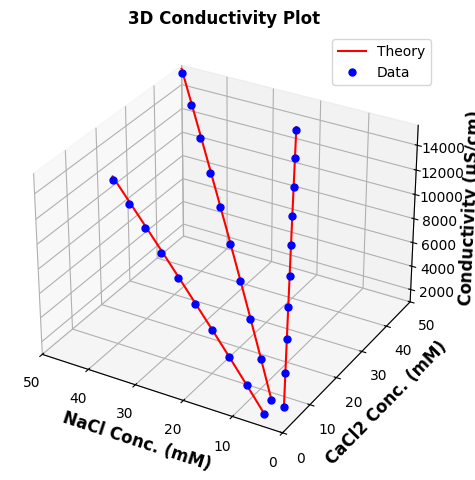

In [8]:
# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, all_cond_calc_con, color="red", label="Theory")
ax.plot3D(NaCl_conc12, CaCl2_conc12, all_cond_calc_con12, color="red")
ax.plot3D(NaCl_conc13, CaCl2_conc13, all_cond_calc_con13, color="red")
ax.plot3D(NaCl_conc, CaCl2_conc, cond_exp, "b.", markersize=10, label="Data")
ax.plot3D(NaCl_conc12, CaCl2_conc12, cond_exp12, "b.", markersize=10)
ax.plot3D(NaCl_conc13, CaCl2_conc13, cond_exp13, "b.", markersize=10)
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaCl2 Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
# plt.savefig("msc_model_na_ca.png")
plt.show()

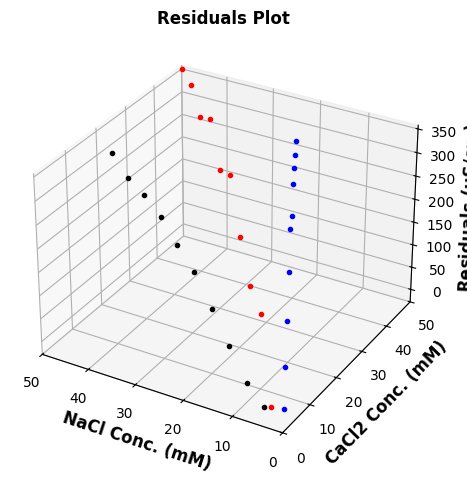

In [9]:
# residuals for NaCl and CaCl2
e = [all_cond_calc_con[i] - cond_exp[i] for i in range(ndata)]
e12 = [all_cond_calc_con12[i] - cond_exp12[i] for i in range(ndata)]
e13 = [all_cond_calc_con13[i] - cond_exp13[i] for i in range(ndata)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, e, "r.")
ax.plot3D(NaCl_conc12, CaCl2_conc12, e12, "b.")
ax.plot3D(NaCl_conc13, CaCl2_conc13, e13, ".", color="black")
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaCl2 Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
# plt.savefig("residuals_msc_model_na_ca.png")
plt.show()

2.871034072820683
2.3240865746735815
2.2340663493475517


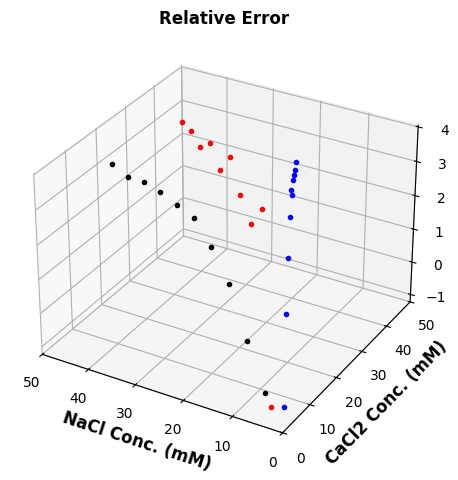

In [10]:
# residuals percent or fraction
residuals_percent = [100*e[i]/cond_exp[i] for i in range(ndata)]
residuals_percent12 = [100*e12[i]/cond_exp12[i] for i in range(ndata)]
residuals_percent13 = [100*e13[i]/cond_exp13[i] for i in range(ndata)]

# absolute value of relative error
residuals_percent_abs = [np.abs(residuals_percent[i]) for i in range(ndata)]
residuals_percent12_abs = [np.abs(residuals_percent12[i]) for i in range(ndata)]
residuals_percent13_abs = [np.abs(residuals_percent13[i]) for i in range(ndata)]
print(np.mean(residuals_percent_abs))
print(np.mean(residuals_percent12_abs))
print(np.mean(residuals_percent13_abs))

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, residuals_percent, "r.")
ax.plot3D(NaCl_conc12, CaCl2_conc12, residuals_percent12, "b.")
ax.plot3D(NaCl_conc13, CaCl2_conc13, residuals_percent13, ".", color="black")
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaCl2 Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
# plt.savefig("proportion_msc_model_na_ca.png")
plt.show()

## CaCl2 and LaCl3

In [11]:
# constants
diffusion_coeff_2 = [Diff_La, Diff_Ca, Diff_Cl] # diffusion coefficients of La, Ca, and Cl, respectively
valency_2 = [z_La, z_Ca, z_Cl] # valencies of La, Ca, and Cl, respectively
diameter_2 = [sigma_La, sigma_Ca, sigma_Cl] # effective ionic diameters of La, Ca, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con2 = msa_conductivity_model(valency_2, diameter_2, diffusion_coeff_2, T, voltage, distance, eta, epsilon, cond_exp2, LaCl3_conc, 
                                            CaCl2_conc2)
all_cond_calc_con22 = msa_conductivity_model(valency_2, diameter_2, diffusion_coeff_2, T, voltage, distance, eta, epsilon, cond_exp22, LaCl3_conc12, 
                                             CaCl2_conc22)
all_cond_calc_con23 = msa_conductivity_model(valency_2, diameter_2, diffusion_coeff_2, T, voltage, distance, eta, epsilon, cond_exp23, LaCl3_conc13, 
                                             CaCl2_conc23)

Relaxation correction: [-3.33895768e-11 -1.54958031e-11 -2.62320673e-11]
Hydrodynamic correction: [-0.47999759 -0.37572146 -0.14023977]
omega_bar: 254998618549.4704
Alpha: [0.0, 177514916972.00076, 357552337024.4243]
Mew: [0.5        0.22222222 0.27777778]
Transport number: [0.2947775  0.16762792 0.53759458]
Omega: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
ksi: [[ 1.49560678 -0.98603166 -0.42812508]
 [ 1.1689149   2.0485397  -0.63459947]
 [ 0.45560069  0.13602522  1.27830472]]
Relaxation correction: [-4.03665564e-11 -1.92994709e-11 -2.83282218e-11]
Hydrodynamic correction: [-0.54336134 -0.42539007 -0.15796272]
omega_bar: 264433392030.6449
Alpha: [0.0, 170446449841.47757, 357402378151.1003]
Mew: [0.375      0.33333333 0.29166667]
Transport number: [0.21319506 0.24247063 0.54433432]
Omega: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
ksi: [[ 1.55828361 -1.44328908 -0.42333097]
 [ 1.21790095  1.49901735 -0.62759471]
 [ 0.47469368  0.14249471  1.26153378]]
Relaxation correction: [-2

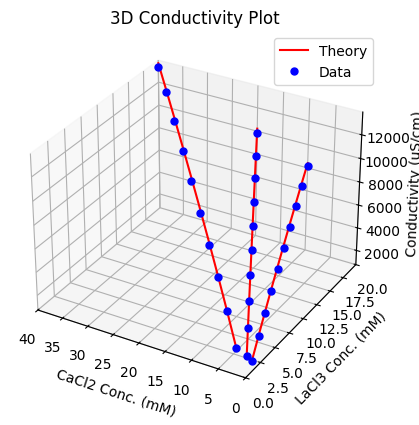

In [12]:
# making plot comparison of calculated and experimental conductivity of CaCl2 and LaCl3
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, all_cond_calc_con2, color="red", label="Theory")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, all_cond_calc_con22, color="red")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, all_cond_calc_con23, color="red")
ax.plot3D(CaCl2_conc2, LaCl3_conc, cond_exp2, "b.", markersize=10, label="Data")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, cond_exp22, "b.", markersize=10)
ax.plot3D(CaCl2_conc23, LaCl3_conc13, cond_exp23, "b.", markersize=10)
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.set_title('3D Conductivity Plot')
ax.set_zlabel("Conductivity (uS/cm)")
ax.set_xlabel("CaCl2 Conc. (mM)")
ax.set_ylabel("LaCl3 Conc. (mM)")
ax.legend()
plt.show()

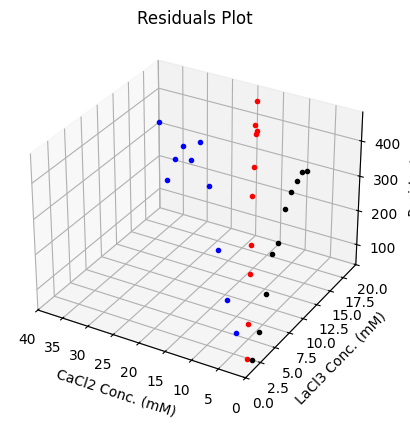

In [13]:
# residuals for CaCl2 and LaCl3
e2 = [all_cond_calc_con2[i] - cond_exp2[i] for i in range(ndata2)]
e22 = [all_cond_calc_con22[i] - cond_exp22[i] for i in range(ndata2)]
e23 = [all_cond_calc_con23[i] - cond_exp23[i] for i in range(ndata2)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, e2, "r.")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, e22, "b.")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, e23, ".", color="black")
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.set_title("Residuals Plot")
ax.set_zlabel("Residuals")
ax.set_xlabel("CaCl2 Conc. (mM)")
ax.set_ylabel("LaCl3 Conc. (mM)")
plt.show()

5.363348215358241
4.387362802998487
5.12705869164647


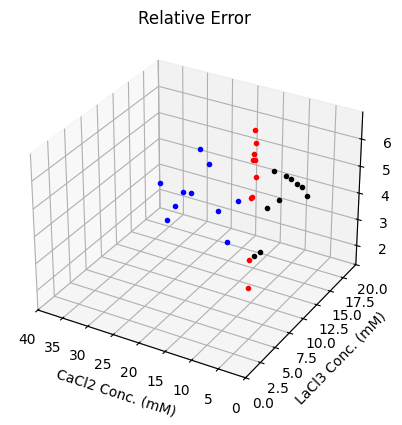

In [14]:
# residuals percent or fraction
residuals_percent2 = [100*e2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent22 = [100*e22[i]/cond_exp22[i] for i in range(ndata2)]
residuals_percent23 = [100*e23[i]/cond_exp23[i] for i in range(ndata2)]

# absolute value of relative error
residuals_percent2_abs = [np.abs(residuals_percent2[i]) for i in range(ndata2)]
residuals_percent22_abs = [np.abs(residuals_percent22[i]) for i in range(ndata2)]
residuals_percent23_abs = [np.abs(residuals_percent23[i]) for i in range(ndata2)]
print(np.mean(residuals_percent2_abs))
print(np.mean(residuals_percent22_abs))
print(np.mean(residuals_percent23_abs))

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, residuals_percent2, "r.")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, residuals_percent22, "b.")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, residuals_percent23, ".", color="black")
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.set_title("Relative Error")
ax.set_zlabel("Residuals (%)")
ax.set_xlabel("CaCl2 Conc. (mM)")
ax.set_ylabel("LaCl3 Conc. (mM)")
plt.show()

## NaCl and LaCl3

In [15]:
# constants
diffusion_coeff_3 = [Diff_La, Diff_Na, Diff_Cl] # diffusion coefficients of La, Na, and Cl, respectively
valency_3 = [z_La, z_Na, z_Cl] # valencies of La, Na, and Cl, respectively
diameter_3 = [sigma_La, sigma_Na, sigma_Cl] # effective ionic diameters of La, Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con3 = msa_conductivity_model(valency_3, diameter_3, diffusion_coeff_3, T, voltage, distance, eta, epsilon, cond_exp3, LaCl3_conc2, 
                                            NaCl_conc2)
all_cond_calc_con32 = msa_conductivity_model(valency_3, diameter_3, diffusion_coeff_3, T, voltage, distance, eta, epsilon, cond_exp32, LaCl3_conc22, 
                                             NaCl_conc22)
all_cond_calc_con33 = msa_conductivity_model(valency_3, diameter_3, diffusion_coeff_3, T, voltage, distance, eta, epsilon, cond_exp33, LaCl3_conc23, 
                                             NaCl_conc23)

Relaxation correction: [-2.95605070e-11 -4.68449807e-12 -2.33415048e-11]
Hydrodynamic correction: [-0.42954208 -0.19913596 -0.12604011]
omega_bar: 260788916222.98755
Alpha: [0.0, 280185123994.9613, 378474712351.47736]
Mew: [0.64285714 0.07142857 0.28571429]
Transport number: [0.37058471 0.08873811 0.54067718]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50778913 -0.58944861 -0.27849707]
 [ 0.69964128  2.68345218 -1.89174574]
 [ 0.45931175  0.65539633  1.09955484]]
Relaxation correction: [-3.84021160e-11 -6.94462386e-12 -2.26733699e-11]
Hydrodynamic correction: [-0.47872796 -0.22184151 -0.14000104]
omega_bar: 293668709070.8091
Alpha: [0.0, 242876329097.13528, 388092787538.26306]
Mew: [0.5        0.16666667 0.33333333]
Transport number: [0.25596141 0.18387319 0.5601654 ]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.69629658 -0.98749428 -0.23296339]
 [ 0.78711213  1.6842391  -1.40795025]
 [ 0.51673602  0.63912188  1.0534202 ]]
Relaxation correction: [

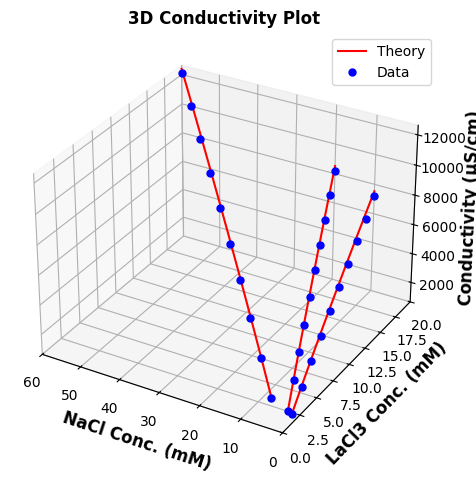

In [16]:
# making plot comparison of calculated and experimental conductivity of NaCl and LaCl3
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, all_cond_calc_con3, color="red", label="Theory")
ax.plot3D(NaCl_conc22, LaCl3_conc22, all_cond_calc_con32, color="red")
ax.plot3D(NaCl_conc23, LaCl3_conc23, all_cond_calc_con33, color="red")
ax.plot3D(NaCl_conc2, LaCl3_conc2, cond_exp3, "b.", markersize=10, label="Data")
ax.plot3D(NaCl_conc22, LaCl3_conc22, cond_exp32, "b.", markersize=10)
ax.plot3D(NaCl_conc23, LaCl3_conc23, cond_exp33, "b.", markersize=10)
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaCl3 Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
# plt.savefig("msc_model_na_la.png")
plt.show()

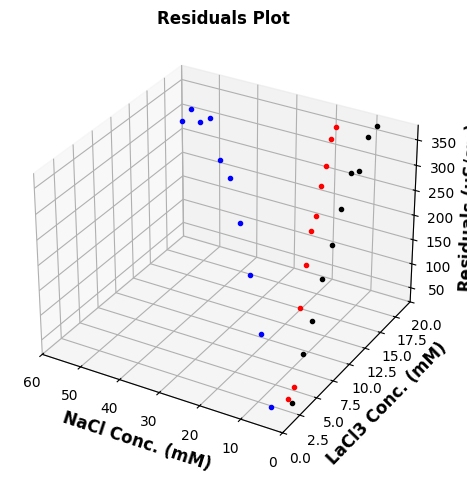

In [17]:
# residuals for NaCl and LaCl3
e3 = [all_cond_calc_con3[i] - cond_exp3[i] for i in range(ndata4)]
e32 = [all_cond_calc_con32[i] - cond_exp32[i] for i in range(ndata4)]
e33 = [all_cond_calc_con33[i] - cond_exp33[i] for i in range(ndata4)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, e3, "r.")
ax.plot3D(NaCl_conc22, LaCl3_conc22, e32, "b.")
ax.plot3D(NaCl_conc23, LaCl3_conc23, e33, ".", color="black")
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaCl3 Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
# plt.savefig("residuals_msc_model_na_la.png")
plt.show()

4.986635403940359
3.907908432701497
6.0899328945030415


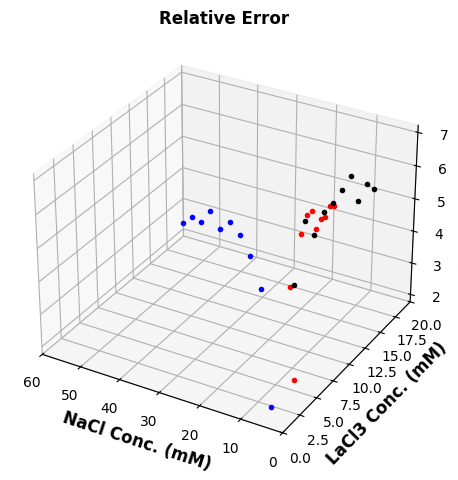

In [18]:
# residuals percent or fraction
residuals_percent3 = [100*e3[i]/cond_exp3[i] for i in range(ndata4)]
residuals_percent32 = [100*e32[i]/cond_exp32[i] for i in range(ndata4)]
residuals_percent33 = [100*e33[i]/cond_exp33[i] for i in range(ndata4)]

# absolute value of relative error
residuals_percent3_abs = [np.abs(residuals_percent3[i]) for i in range(ndata4)]
residuals_percent32_abs = [np.abs(residuals_percent32[i]) for i in range(ndata4)]
residuals_percent33_abs = [np.abs(residuals_percent33[i]) for i in range(ndata4)]
print(np.mean(residuals_percent3_abs))
print(np.mean(residuals_percent32_abs))
print(np.mean(residuals_percent33_abs))

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, residuals_percent3, "r.")
ax.plot3D(NaCl_conc22, LaCl3_conc22, residuals_percent32, "b.")
ax.plot3D(NaCl_conc23, LaCl3_conc23, residuals_percent33, ".", color="black")
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaCl3 Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
# plt.savefig("proportion_msc_model_na_la.png")
plt.show()

# Single Salts (NaCl)

## Data for NaCl

In [19]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl_cleaned.csv")
conc_nacl = specific_data["NaCl conc"]
cond_exp_nacl = specific_data["NaCl cond cal"]

# number of data points
ndata_nacl = len(cond_exp_nacl)

## NaCl Predictions

In [20]:
# constants
diffusion_coeff_4 = [Diff_Na, Diff_Cl] # diffusion coefficients of Na, and Cl, respectively
valency_4 = [z_Na, z_Cl] # valencies of Na, and Cl, respectively
diameter_4 = [sigma_Na, sigma_Cl] # effective ionic diameters of Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con4 = mc.msa_conductivity_model(valency_4, diameter_4, diffusion_coeff_4, T, voltage, distance, eta, epsilon, cond_exp_nacl, conc_nacl)

Relaxation correction: [-9.28759514e-12 -9.28759514e-12]
Hydrodynamic correction: [-0.17001264 -0.10854922]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]


In [21]:
# constants
sigma_Na_reg = 100*10**(-12)
diameter_4_reg = [sigma_Na_reg, sigma_Cl] # effective ionic diameters of Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con4_reg = mc.msa_conductivity_model(valency_4, diameter_4_reg, diffusion_coeff_4, T, voltage, distance, eta, epsilon, cond_exp_nacl, 
                                                   conc_nacl)

Relaxation correction: [-9.22839514e-12 -9.22839514e-12]
Hydrodynamic correction: [-0.17023586 -0.10860513]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]


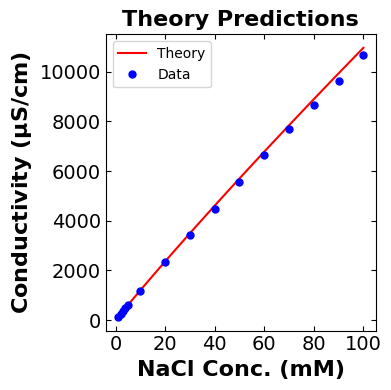

In [22]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, all_cond_calc_con4, "r-", label="Theory")
plt.plot(conc_nacl, cond_exp_nacl, "b.", markersize=10, label="Data")
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Theory Predictions", fontsize=16,fontweight='bold')
plt.legend()
plt.tight_layout()
# plt.savefig("msc_model_na.png")
plt.show()

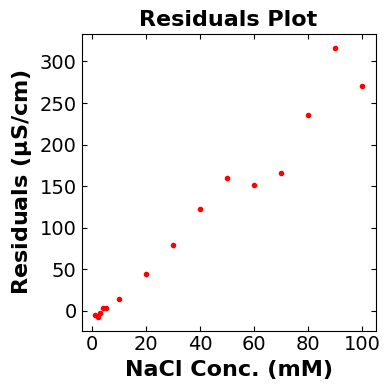

In [23]:
# residuals
e_nacl = [all_cond_calc_con4[i] - cond_exp_nacl[i] for i in range(ndata_nacl)]
e_nacl_reg = [all_cond_calc_con4_reg[i] - cond_exp_nacl[i] for i in range(ndata_nacl)]

# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, e_nacl, "r.")
plt.title("Residuals Plot", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.tight_layout()
# plt.savefig("residuals_msc_model_na.png")
plt.show()

2.215859736511185


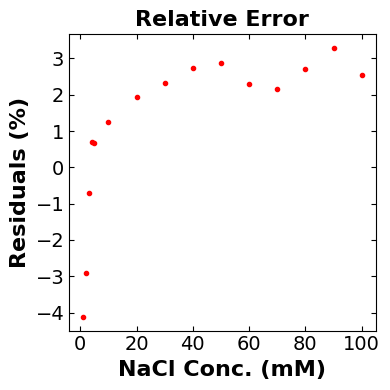

In [24]:
# residuals percent or fraction
residuals_percent_nacl = [100*e_nacl[i]/cond_exp_nacl[i] for i in range(ndata_nacl)]

# absolute value of relative error
residuals_percent_nacl_abs = [np.abs(residuals_percent_nacl[i]) for i in range(ndata_nacl)]
print(np.mean(residuals_percent_nacl_abs))

# visualizing in plot
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, residuals_percent_nacl, "r.")
plt.title("Relative Error", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.tight_layout()
# plt.savefig("proportion_msc_model_na.png")
plt.show()

# Shedlovsky Model

## NaCl

In [25]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl.csv")
molar_conc_specific_Na = specific_data["NaCl conc"]
specific_cond_exp_Na = specific_data["NaCl cond"]
specific_cond_calibrated_Na = specific_data["NaCl cond cal"]

# number of data points
ndata3 = len(specific_cond_exp_Na)

# constants
temp_NaCl = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
lambda_0_NaCl = 126.45 # cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
a_NaCl = 4*10**(-8) # cm
z_Na = 1
z_Cl = -1

In [26]:
# concentration in M
conc2 = [molar_conc_specific_Na[i]*10**(-3) for i in range(ndata3)]

# specific conductivity in micro Siemen per cm
specific_cond_calc_Na = eq.specific_cond_model(conc2, temp_NaCl, epsilon, eta, lambda_0_NaCl, a_NaCl, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

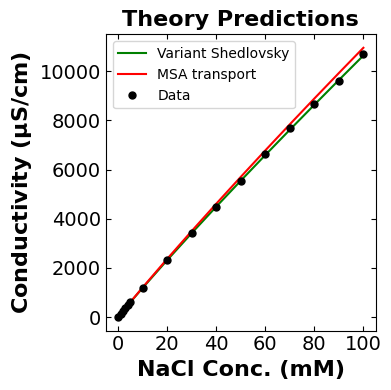

In [27]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_Na, specific_cond_calc_Na, color="green", label="Variant Shedlovsky")
plt.plot(conc_nacl, all_cond_calc_con4, "r-", label="MSA transport")
# plt.plot(conc_nacl, all_cond_calc_con4_reg, "b-", label="MSA transport regressed")
plt.plot(molar_conc_specific_Na, specific_cond_calibrated_Na, ".", color="black", markersize=10, label="Data")
plt.title("Theory Predictions", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.tight_layout()
# plt.savefig("msc_single_model_comparison.png")
# plt.savefig("msc_single_model_comparison2.png")
plt.show()

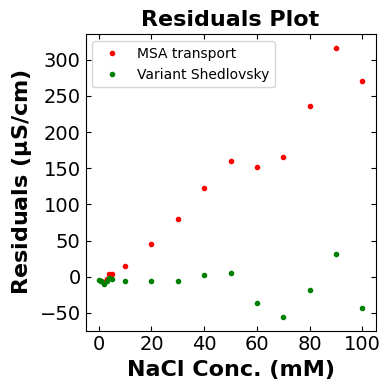

In [28]:
# residuals
residuals_Na = [specific_cond_calc_Na[i] - specific_cond_calibrated_Na[i] for i in range(ndata3)]

# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, e_nacl, "r.", label="MSA transport")
# plt.plot(conc_nacl, e_nacl_reg, "b.", label="MSA transport regressed")
plt.plot(molar_conc_specific_Na, residuals_Na, ".", color="green", label="Variant Shedlovsky")
plt.title("Residuals Plot", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.tight_layout()
# plt.savefig("residuals_msc_single_comparison.png")
# plt.savefig("residuals_msc_single_comparison2.png")
plt.show()

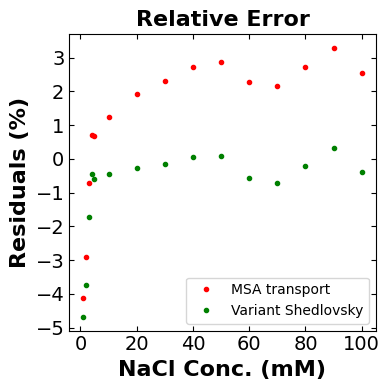

In [29]:
# residuals percent or fraction
residuals_percent_Na = [100*residuals_Na[i]/specific_cond_calibrated_Na[i] for i in range(ndata3)]
residuals_percent_clean = residuals_percent_Na[1:]
molar_conc_specific_Na_clean = molar_conc_specific_Na[1:]

# visualizing in plot
fig = plt.figure(figsize=(4,4))
plt.plot(conc_nacl, residuals_percent_nacl, "r.", label="MSA transport")
plt.plot(molar_conc_specific_Na_clean, residuals_percent_clean, ".", color="green", label="Variant Shedlovsky")
plt.title("Relative Error", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.tight_layout()
# plt.savefig("proportion_msc_single_comparison.png")
plt.show()

## NaCl and CaCl2 Model Comparison

### NaCl

In [30]:
# constants
temp_NaCl_CaCl2 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_CaCl2 = 4.31*10**(-8) # cm
a_NaCl_CaCl2 = (a_NaCl + a_CaCl2)/2

# concentration in M
conc = [NaCl_conc[i]*10**(-3) for i in range(ndata)]
conc12 = [NaCl_conc12[i]*10**(-3) for i in range(ndata)]
conc13 = [NaCl_conc13[i]*10**(-3) for i in range(ndata)]

# specific conductivity in micro Siemen per cm
specific_cond_nacl = eq.specific_cond_model(conc, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_12 = eq.specific_cond_model(conc12, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_13 = eq.specific_cond_model(conc13, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

## CaCl2

In [31]:
# constants
lambda_0_CaCl2 = 135.85 # cm^2.Siemen.equiv^(-1)
lambda_0_Ca = 59.5 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
z_Ca = 2
z_Cl = -1

# concentration in M
conc_cacl2 = [CaCl2_conc[i]*10**(-3) for i in range(ndata)]
conc_cacl2_12 = [CaCl2_conc12[i]*10**(-3) for i in range(ndata)]
conc_cacl2_13 = [CaCl2_conc13[i]*10**(-3) for i in range(ndata)]

# specific conductivity in micro Siemen per cm
specific_cond_cacl2 = eq.specific_cond_model(conc_cacl2, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                             lambda_0_Cl)
specific_cond_cacl2_12 = eq.specific_cond_model(conc_cacl2_12, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                                lambda_0_Cl)
specific_cond_cacl2_13 = eq.specific_cond_model(conc_cacl2_13, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                                lambda_0_Cl)

## NaCl & CaCl2

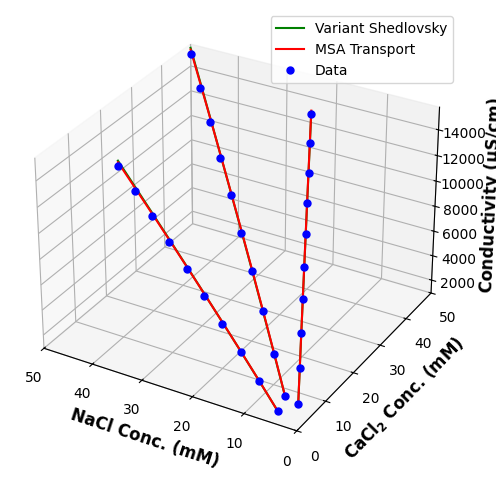

In [32]:
# bulk conductivity
specific_cond = [specific_cond_nacl[i] + specific_cond_cacl2[i] for i in range(ndata)]
specific_cond_12 = [specific_cond_nacl_12[i] + specific_cond_cacl2_12[i] for i in range(ndata)]
specific_cond_13 = [specific_cond_nacl_13[i] + specific_cond_cacl2_13[i] for i in range(ndata)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, specific_cond, color="green", label="Variant Shedlovsky")
ax.plot3D(NaCl_conc12, CaCl2_conc12, specific_cond_12, color="green")
ax.plot3D(NaCl_conc13, CaCl2_conc13, specific_cond_13, color="green")
ax.plot3D(NaCl_conc, CaCl2_conc, all_cond_calc_con, color="red", label="MSA Transport")
ax.plot3D(NaCl_conc12, CaCl2_conc12, all_cond_calc_con12, color="red")
ax.plot3D(NaCl_conc13, CaCl2_conc13, all_cond_calc_con13, color="red")
ax.plot3D(NaCl_conc, CaCl2_conc, cond_exp, "b.", markersize=10, label="Data")
ax.plot3D(NaCl_conc12, CaCl2_conc12, cond_exp12, "b.", markersize=10)
ax.plot3D(NaCl_conc13, CaCl2_conc13, cond_exp13, "b.", markersize=10)
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("msc_single_na_ca_comparison.png")
plt.show()

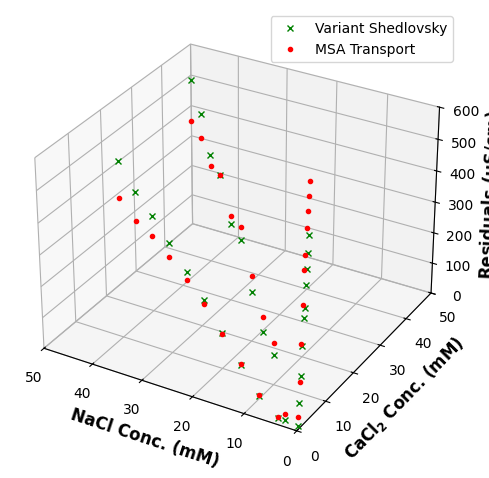

In [33]:
# residuals for NaCl and CaCl2
e_2 = [specific_cond[i] - cond_exp[i] for i in range(ndata)]
e12_2 = [specific_cond_12[i] - cond_exp12[i] for i in range(ndata)]
e13_2 = [specific_cond_13[i] - cond_exp13[i] for i in range(ndata)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, e_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(NaCl_conc12, CaCl2_conc12, e12_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc13, CaCl2_conc13, e13_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc, CaCl2_conc, e, ".", color="red", label="MSA Transport")
ax.plot3D(NaCl_conc12, CaCl2_conc12, e12, ".", color="red")
ax.plot3D(NaCl_conc13, CaCl2_conc13, e13, ".", color="red")
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.set_zlim(0, 600)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("residuals_msc_single_na_ca_comparison.png")
plt.show()

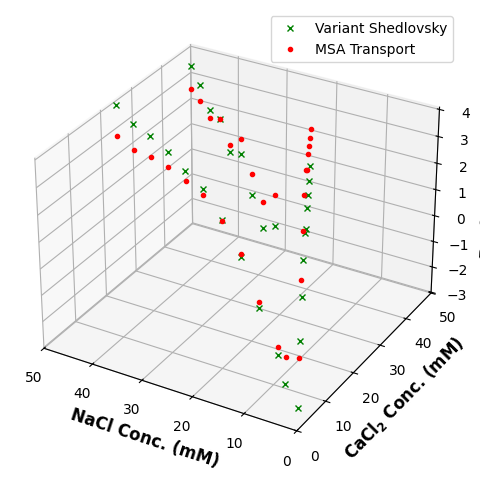

In [34]:
# residuals fraction
residuals_percent_2 = [100*e_2[i]/cond_exp[i] for i in range(ndata)]
residuals_percent12_2 = [100*e12_2[i]/cond_exp12[i] for i in range(ndata)]
residuals_percent13_2 = [100*e13_2[i]/cond_exp13[i] for i in range(ndata)]

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc, CaCl2_conc, residuals_percent_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(NaCl_conc12, CaCl2_conc12, residuals_percent12_2, "x", color="green", markersize=5)
ax.plot3D(NaCl_conc13, CaCl2_conc13, residuals_percent13_2, "x", color="green", markersize=5)
ax.plot3D(NaCl_conc, CaCl2_conc, residuals_percent, "r.", label="MSA Transport")
ax.plot3D(NaCl_conc12, CaCl2_conc12, residuals_percent12, "r.")
ax.plot3D(NaCl_conc13, CaCl2_conc13, residuals_percent13, "r.")
ax.set_xlim(50, 0)
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("proportion_msc_single_na_ca_comparison.png")
plt.show()

## NaCl and LaCl3 Model Comparison

### NaCl

In [35]:
# constants
temp_NaCl_LaCl3 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_LaCl3 = 4.9*10**(-8) # cm
a_NaCl_LaCl3 = (a_NaCl + a_LaCl3)/2

# concentration in M
conc_nacl_21 = [NaCl_conc2[i]*10**(-3) for i in range(ndata4)]
conc_nacl_22 = [NaCl_conc22[i]*10**(-3) for i in range(ndata4)]
conc_nacl_23 = [NaCl_conc23[i]*10**(-3) for i in range(ndata4)]

# specific conductivity in micro Siemen per cm
specific_cond_nacl_21 = eq.specific_cond_model(conc_nacl_21, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)
specific_cond_nacl_22 = eq.specific_cond_model(conc_nacl_22, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)
specific_cond_nacl_23 = eq.specific_cond_model(conc_nacl_23, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)

### LaCl3

In [36]:
# constants
lambda_0_LaCl3 = 145.9 # cm^2.Siemen.equiv^(-1)
lambda_0_La = 69.7 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
z_La = 3
z_Cl = -1

# concentration in M
conc_lacl3_11 = [LaCl3_conc2[i]*10**(-3) for i in range(ndata4)]
conc_lacl3_12 = [LaCl3_conc22[i]*10**(-3) for i in range(ndata4)]
conc_lacl3_13 = [LaCl3_conc23[i]*10**(-3) for i in range(ndata4)]

# specific conductivity in micro Siemen per cm
specific_cond_lacl3_11 = eq.specific_cond_model(conc_lacl3_11, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)
specific_cond_lacl3_12 = eq.specific_cond_model(conc_lacl3_12, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)
specific_cond_lacl3_13 = eq.specific_cond_model(conc_lacl3_13, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)

### NaCl & LaCl3

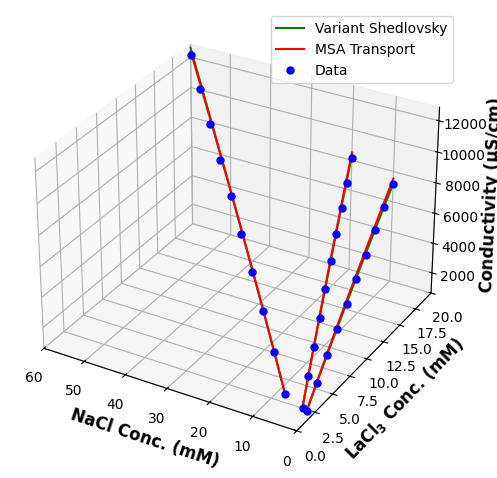

In [37]:
# bulk conductivity
specific_cond_21 = [specific_cond_nacl_21[i] + specific_cond_lacl3_11[i] for i in range(ndata4)]
specific_cond_22 = [specific_cond_nacl_22[i] + specific_cond_lacl3_12[i] for i in range(ndata4)]
specific_cond_23 = [specific_cond_nacl_23[i] + specific_cond_lacl3_13[i] for i in range(ndata4)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, specific_cond_21, color="green", label="Variant Shedlovsky")
ax.plot3D(NaCl_conc22, LaCl3_conc22, specific_cond_22, color="green")
ax.plot3D(NaCl_conc23, LaCl3_conc23, specific_cond_23, color="green")
ax.plot3D(NaCl_conc2, LaCl3_conc2, all_cond_calc_con3, color="red", label="MSA Transport")
ax.plot3D(NaCl_conc22, LaCl3_conc22, all_cond_calc_con32, color="red")
ax.plot3D(NaCl_conc23, LaCl3_conc23, all_cond_calc_con33, color="red")
ax.plot3D(NaCl_conc2, LaCl3_conc2, cond_exp3, "b.", markersize=10, label="Data")
ax.plot3D(NaCl_conc22, LaCl3_conc22, cond_exp32, "b.", markersize=10)
ax.plot3D(NaCl_conc23, LaCl3_conc23, cond_exp33, "b.", markersize=10)
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("msc_single_na_la_comparison.png")
plt.show()

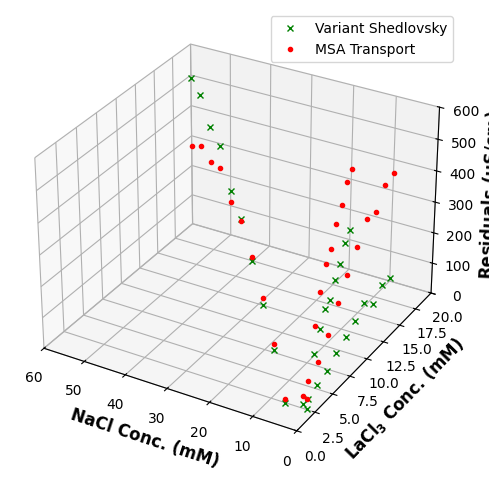

In [38]:
# residuals for NaCl and LaCl3
e3_2 = [specific_cond_21[i] - cond_exp3[i] for i in range(ndata4)]
e32_2 = [specific_cond_22[i] - cond_exp32[i] for i in range(ndata4)]
e33_2 = [specific_cond_23[i] - cond_exp33[i] for i in range(ndata4)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, e3_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(NaCl_conc22, LaCl3_conc22, e32_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc23, LaCl3_conc23, e33_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc2, LaCl3_conc2, e3, ".", color="red", label="MSA Transport")
ax.plot3D(NaCl_conc22, LaCl3_conc22, e32, ".", color="red")
ax.plot3D(NaCl_conc23, LaCl3_conc23, e33, ".", color="red")
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.set_zlim(0, 600)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("residuals_msc_single_na_la_comparison.png")
plt.show()

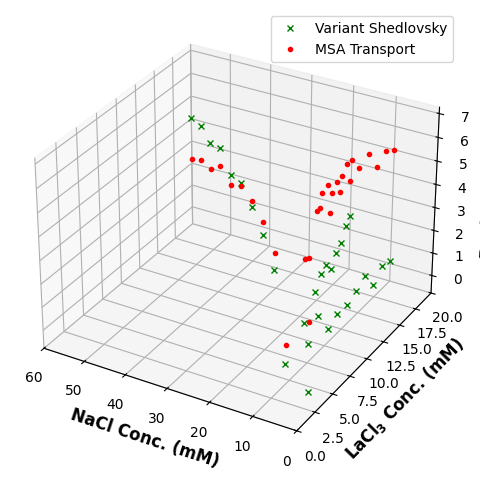

In [39]:
# residuals fraction
residuals_percent3_2 = [100*e3_2[i]/cond_exp3[i] for i in range(ndata4)]
residuals_percent32_2 = [100*e32_2[i]/cond_exp32[i] for i in range(ndata4)]
residuals_percent33_2 = [100*e33_2[i]/cond_exp33[i] for i in range(ndata4)]

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc2, LaCl3_conc2, residuals_percent3_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(NaCl_conc22, LaCl3_conc22, residuals_percent32_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc23, LaCl3_conc23, residuals_percent33_2, "x", markersize=5, color="green")
ax.plot3D(NaCl_conc2, LaCl3_conc2, residuals_percent3, ".", color="red", label="MSA Transport")
ax.plot3D(NaCl_conc22, LaCl3_conc22, residuals_percent32, ".", color="red")
ax.plot3D(NaCl_conc23, LaCl3_conc23, residuals_percent33, ".", color="red")
ax.set_xlim(60, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("proportion_msc_single_na_la_comparison.png")
plt.show()

## CaCl2 and LaCl3 Model Comparison

### CaCl2

In [40]:
# constants
temp_CaCl2_LaCl3 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_CaCl2_LaCl3 = (a_CaCl2 + a_LaCl3)/2

# concentration in M
conc_cacl2_21 = [CaCl2_conc2[i]*10**(-3) for i in range(ndata2)]
conc_cacl2_22 = [CaCl2_conc22[i]*10**(-3) for i in range(ndata2)]
conc_cacl2_23 = [CaCl2_conc23[i]*10**(-3) for i in range(ndata2)]

# specific conductivity in micro Siemen per cm
specific_cond_cacl2_21 = eq.specific_cond_model(conc_cacl2_21, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)
specific_cond_cacl2_22 = eq.specific_cond_model(conc_cacl2_22, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)
specific_cond_cacl2_23 = eq.specific_cond_model(conc_cacl2_23, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)

### LaCl3

In [41]:
# concentration in M
conc_lacl3_21 = [LaCl3_conc[i]*10**(-3) for i in range(ndata2)]
conc_lacl3_22 = [LaCl3_conc12[i]*10**(-3) for i in range(ndata2)]
conc_lacl3_23 = [LaCl3_conc13[i]*10**(-3) for i in range(ndata2)]

# specific conductivity in micro Siemen per cm
specific_cond_lacl3_21 = eq.specific_cond_model(conc_lacl3_21, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)
specific_cond_lacl3_22 = eq.specific_cond_model(conc_lacl3_22, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)
specific_cond_lacl3_23 = eq.specific_cond_model(conc_lacl3_23, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)

### CaCl2 and LaCl3

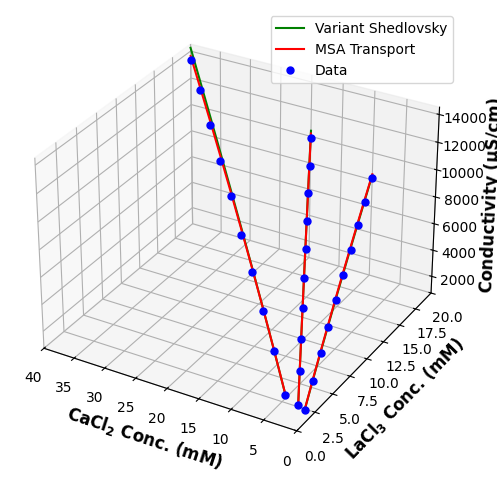

In [42]:
# bulk conductivity
specific_cond_31 = [specific_cond_cacl2_21[i] + specific_cond_lacl3_21[i] for i in range(ndata2)]
specific_cond_32 = [specific_cond_cacl2_22[i] + specific_cond_lacl3_22[i] for i in range(ndata2)]
specific_cond_33 = [specific_cond_cacl2_23[i] + specific_cond_lacl3_23[i] for i in range(ndata2)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, specific_cond_31, color="green", label="Variant Shedlovsky")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, specific_cond_32, color="green")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, specific_cond_33, color="green")
ax.plot3D(CaCl2_conc2, LaCl3_conc, all_cond_calc_con2, color="red", label="MSA Transport")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, all_cond_calc_con22, color="red")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, all_cond_calc_con23, color="red")
ax.plot3D(CaCl2_conc2, LaCl3_conc, cond_exp2, "b.", markersize=10, label="Data")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, cond_exp22, "b.", markersize=10)
ax.plot3D(CaCl2_conc23, LaCl3_conc13, cond_exp23, "b.", markersize=10)
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("msc_single_ca_la_comparison.png")
plt.show()

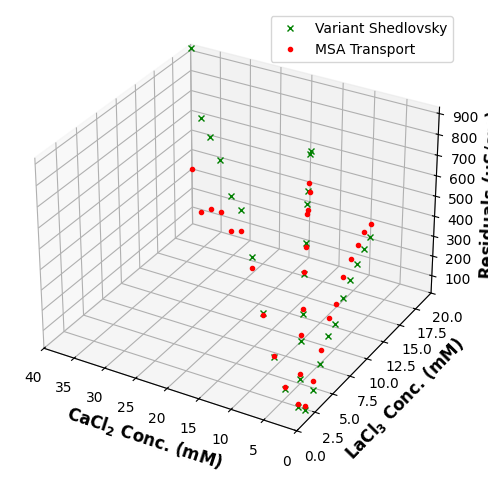

In [43]:
# residuals for CaCl2 and LaCl3
e2_2 = [specific_cond_31[i] - cond_exp2[i] for i in range(ndata2)]
e22_2 = [specific_cond_32[i] - cond_exp22[i] for i in range(ndata2)]
e23_2 = [specific_cond_33[i] - cond_exp23[i] for i in range(ndata2)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, e2_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, e22_2, "x", markersize=5, color="green")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, e23_2, "x", markersize=5, color="green")
ax.plot3D(CaCl2_conc2, LaCl3_conc, e2, ".", color="red", label="MSA Transport")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, e22, ".", color="red")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, e23, ".", color="red")
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("residuals_msc_single_ca_la_comparison.png")
plt.show()

5.56479669302488
6.213878603615317
3.208647694457556


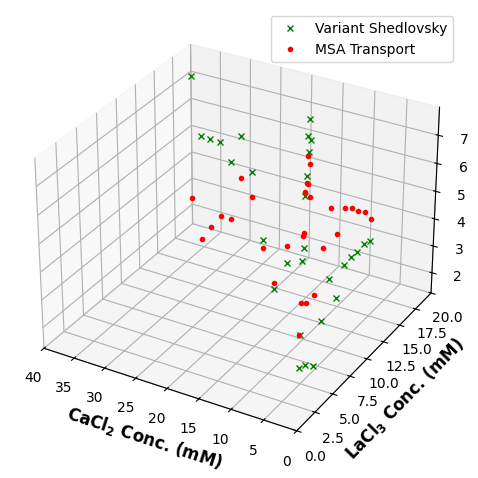

In [44]:
# residuals fraction
residuals_percent2_2 = [100*e2_2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent22_2 = [100*e22_2[i]/cond_exp22[i] for i in range(ndata2)]
residuals_percent23_2 = [100*e23_2[i]/cond_exp23[i] for i in range(ndata2)]

# absolute value of relative error
residuals_percent2_2_abs = [np.abs(residuals_percent2_2[i]) for i in range(ndata2)]
residuals_percent22_2_abs = [np.abs(residuals_percent22_2[i]) for i in range(ndata2)]
residuals_percent23_2_abs = [np.abs(residuals_percent23_2[i]) for i in range(ndata2)]
print(np.mean(residuals_percent2_2_abs))
print(np.mean(residuals_percent22_2_abs))
print(np.mean(residuals_percent23_2_abs))

# making plot
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc2, LaCl3_conc, residuals_percent2_2, "x", color="green", markersize=5, label="Variant Shedlovsky")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, residuals_percent22_2, "x", markersize=5, color="green")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, residuals_percent23_2, "x", markersize=5, color="green")
ax.plot3D(CaCl2_conc2, LaCl3_conc, residuals_percent2, ".", color="red", label="MSA Transport")
ax.plot3D(CaCl2_conc22, LaCl3_conc12, residuals_percent22, ".", color="red")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, residuals_percent23, ".", color="red")
ax.set_xlim(40, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
# ax.set_title("Relative Error", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals (%)", fontsize=12,fontweight='bold')
ax.set_xlabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("proportion_msc_single_ca_la_comparison.png")
plt.show()